## Xiaoyu_Yang_2468581_ACC102_Task 1

## Problem Definition

This analysis examines financial performance trends of Chinese listed commercial banks from 2020 to 2024, focusing on profitability (ROE), leverage (debt-to-asset), and growth (CAGR) across different bank size tiers.

**Target Audience:** Finance students, investment analysts, and banking researchers.

## 1. README

#### How to Run This Code
1. Install dependencies: `pip install -r requirements.txt`
   - If using Jupyter Notebook, you can also run: `%pip install pandas numpy matplotlib seaborn wrds`
2. Replace WRDS username in the first cell or set environment variable
3. Run all cells in order
4. Output will be saved to `./output/` folder

#### Data Source
- **Platform:** WRDS (Wharton Research Data Services)
- **Database:** CSMAR - `csmar_financial`
- **Table:** `fs_bcombas` (bank annual financial statements)
- **Access Date:** April 2026
- **Time Period:** 2020–2024 (5 complete years)

## 2. Selection of Table

In [1]:
# Selection of Table

import wrds
db = wrds.Connection()
library = "csmar_financial"

tables = db.list_tables(library=library)
print(f"Total tables: {len(tables)}")
for t in tables:
    if any(k in t.lower() for k in ["fin", "fs", "income", "balance", "statement", "list", "china"]):
        print(t)

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\86136\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Total tables: 20
fs_bcombas
fs_bcomins
fs_bcomscfd
fs_bcomscfi
fs_combas
fs_comins
fs_comscfd
fs_comscfi
fs_icombas
fs_icomins
fs_icomscfd
fs_icomscfi
fs_scombas
fs_scomins
fs_scomscfd
fs_scomscfi
wrds_csmar_financial_master


**Why `fs_bcombas`?**  
This table contains annual bank financial statements with all required variables: total assets, liabilities, operating income, net profit, and equity. One record per bank per year, ideal for panel analysis.

## 3. CODE and OUTPUT


#### 3.1. Environment Setup & Adaptive Data Extraction Engine


In [2]:
import os
import re
import warnings
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional

import pandas as pd
import numpy as np
import wrds
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore")

# %% [markdown]
"""
### 1.1 Intelligent Column Mapping System
Implements fuzzy matching with 90% similarity threshold to handle CSMAR schema variations.
"""

# %%
class AdaptiveColumnMapper:
    """
    Adaptive schema recognition engine for WRDS/CSMAR financial databases.
    Eliminates hard-coded dependencies through fuzzy matching algorithms.
    """

    CANDIDATE_POOL = {
        "Stkcd": ["stkcd", "stock_code", "seccode", "symbol", "ticker", "股票代码"],
        "Company_name": ["company_name", "company", "compnm", "name", "entname", "comnm", "shortname", "公司名称"],
        "Year": ["year", "fyear", "accper", "enddate", "report_year", "ann_year", "会计年度"],
        "Total_assets": ["total_assets", "tot_assets", "assets_total", "a001000000", "b001000000", "总资产"],
        "Total_liabilities": ["total_liabilities", "tot_liab", "liabilities_total", "a002000000", "b002000000", "总负债"],
        "Operating_income": [
            "operating_income", "op_income", "revenue", "sales", 
            "b001100000", "a001101000", "a003111000", "营业收入",
            "operating_revenue", "op_rev", "total_revenue", "营业总收入"
        ],
        "Net_profit": ["net_profit", "net_income", "profit", "b002000000", "a003000000", "净利润", "net_profit_after_tax"],
        "Equity": ["equity", "shareholders_equity", "owner_equity", "a003200000", "b003000000", "股东权益", "total_equity"],
    }

    def __init__(self, similarity_threshold: float = 0.85):  # Lowered threshold for better matching
        self.threshold = similarity_threshold
        self.match_log: List[Dict] = []

    @staticmethod
    def _normalize(name: str) -> str:
        """Normalize column names for robust matching."""
        name = str(name).strip().lower()
        name = re.sub(r"[^a-z0-9_\u4e00-\u9fff]+", "_", name)
        name = re.sub(r"_+", "_", name).strip("_")
        return name

    def match(self, available_columns: List[str], target_field: str) -> Optional[str]:
        """
        Two-phase matching: exact candidate match -> fuzzy similarity match.
        Returns original column name or None if unmatched.
        """
        norm_to_raw = {self._normalize(c): c for c in available_columns}
        norm_available = list(norm_to_raw.keys())
        candidates = self.CANDIDATE_POOL.get(target_field, [])

        # Phase 1: exact normalized match
        for candidate in candidates:
            norm_cand = self._normalize(candidate)
            if norm_cand in norm_to_raw:
                self._log_match(target_field, norm_to_raw[norm_cand], "exact", 1.0)
                return norm_to_raw[norm_cand]

        # Phase 2: fuzzy match
        for candidate in candidates:
            norm_cand = self._normalize(candidate)
            hits = get_close_matches(norm_cand, norm_available, n=1, cutoff=self.threshold)
            if hits:
                sim = self._calculate_similarity(norm_cand, hits[0])
                self._log_match(target_field, norm_to_raw[hits[0]], "fuzzy", sim)
                return norm_to_raw[hits[0]]

        self._log_match(target_field, None, "failed", 0.0)
        return None

    @staticmethod
    def _calculate_similarity(s1: str, s2: str) -> float:
        from difflib import SequenceMatcher
        return SequenceMatcher(None, s1, s2).ratio()

    def _log_match(self, target: str, matched: Optional[str], method: str, score: float):
        self.match_log.append({
            "target_field": target,
            "matched_column": matched,
            "method": method,
            "confidence_score": score,
            "timestamp": datetime.now().isoformat()
        })

    def get_match_report(self) -> pd.DataFrame:
        return pd.DataFrame(self.match_log)

# %% [markdown]
"""
### 1.2 Temporal Data Validator
Handles multi-format year parsing with strict 2020-2024 boundary enforcement.
"""

# %%
class TemporalValidator:
    """Robust year extraction and validation for financial reporting periods."""

    def __init__(self, start_year: int = 2020, end_year: int = 2024):
        self.start = start_year
        self.end = end_year

    def parse(self, series: pd.Series) -> pd.Series:
        """
        Extract 4-digit years from heterogeneous formats.
        Returns Int64 dtype with out-of-range values set to NA.
        """
        s = series.astype(str).str.strip()
        years = pd.to_numeric(s, errors="coerce")

        invalid_mask = ~years.between(1900, 2100, inclusive="both")
        if invalid_mask.any():
            extracted = s[invalid_mask].str.extract(r"((?:19|20)\d{2})", expand=False)
            years.loc[invalid_mask] = pd.to_numeric(extracted, errors="coerce")

        years = years.round().astype("Int64")
        return years.where(years.between(self.start, self.end, inclusive="both"))




#### 3.2 Data Acquisition & Quality Assurance



In [3]:
# Configuration - FIXED PATH to avoid permission issues
WRDS_USERNAME = input("Enter your WRDS username: ")
LIBRARY = "csmar_financial"
TABLE = "fs_bcombas"

START_YEAR = 2020
END_YEAR = 2024

# Use Desktop instead : drive to avoid permission issues
OUTPUT_PATH = Path.home() / "Desktop" / "fs_bcombas_enhanced_2020_2024.csv"
FIGURE_PATH = Path.home() / "Desktop" / "banking_figures"
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

required_fields = [
    "Stkcd", "Year", "Total_assets", "Total_liabilities",
    "Operating_income", "Net_profit", "Equity"
]
optional_fields = ["Company_name"]

column_mapper = AdaptiveColumnMapper(similarity_threshold=0.85)  # Lowered to 0.85
year_validator = TemporalValidator(start_year=START_YEAR, end_year=END_YEAR)

print("=" * 60)
print("CONNECTING TO WRDS DATABASE")
print("=" * 60)
print(f"Library: {LIBRARY}")
print(f"Table: {TABLE}")
print(f"Year range: {START_YEAR}-{END_YEAR}")
print()

db = wrds.Connection(wrds_username=WRDS_USERNAME)

try:
    # First, let's examine available columns
    preview = db.get_table(library=LIBRARY, table=TABLE, obs=5)
    source_columns = list(preview.columns)
    print(f"✓ Found {len(source_columns)} columns in source table")
    print(f"  Sample columns: {source_columns[:15]}")
    print()

    field_mapping = {}
    for field in required_fields + optional_fields:
        field_mapping[field] = column_mapper.match(source_columns, field)

    # Show mapping results
    print("COLUMN MAPPING RESULTS:")
    for field in required_fields + optional_fields:
        matched = field_mapping[field]
        if matched:
            print(f"  ✓ {field:18s} -> {matched}")
        else:
            print(f"  ✗ {field:18s} -> NOT FOUND")

    # Check for unresolved fields
    unresolved = [f for f in required_fields if field_mapping[f] is None]
    if unresolved:
        print(f"\n⚠️  WARNING: Unresolved fields: {unresolved}")
        print("Attempting alternative matching with lower threshold...")
        
        # Try again with even lower threshold for critical fields
        for field in unresolved:
            print(f"  Retrying {field}...")
            # Manual inspection of columns
            for col in source_columns:
                col_lower = col.lower()
                if any(keyword in col_lower for keyword in ["income", "revenue", "sales", "营业"]):
                    field_mapping[field] = col
                    print(f"    ✓ Manual match: {field} -> {col}")
                    break
            
            if field_mapping[field] is None:
                raise ValueError(f"Cannot map required field: {field}. Available columns: {source_columns[:20]}")
    
    print("\n✓ All required fields mapped successfully!")

    selected_cols = [v for v in field_mapping.values() if v is not None]
    print(f"\nDownloading data...")
    raw_data = db.get_table(library=LIBRARY, table=TABLE, columns=selected_cols, obs=-1).copy()
    print(f"✓ Downloaded {len(raw_data):,} raw records")

finally:
    db.close()
    print("✓ Database connection closed")

# %% [markdown]
"""
### 3.2.1 Data Cleaning
"""

# %%
rename_map = {v: k for k, v in field_mapping.items() if v is not None}
df = raw_data.rename(columns=rename_map).copy()

print("\n" + "=" * 60)
print("DATA CLEANING PROCESS")
print("=" * 60)

# year filter
df["Year"] = year_validator.parse(df["Year"])
n0 = len(df)
df = df[df["Year"].notna()].copy()
print(f"✓ Temporal filtering: {n0:,} -> {len(df):,} records ({START_YEAR}-{END_YEAR})")

# stock code cleaning
df["Stkcd"] = df["Stkcd"].astype(str).str.strip().str.zfill(6)
df = df[df["Stkcd"].str.match(r"^\d{6}$", na=False)].copy()
print(f"✓ Stock code validation: {len(df)} records remain")

# optional company name cleaning
if "Company_name" in df.columns:
    df["Company_name"] = df["Company_name"].astype(str).str.strip()
    df.loc[df["Company_name"].str.lower().isin(["", "nan", "none", "null"]), "Company_name"] = pd.NA
    print(f"✓ Company names cleaned")

# numeric conversion
numeric_fields = ["Total_assets", "Total_liabilities", "Operating_income", "Net_profit", "Equity"]
for c in numeric_fields:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
print(f"✓ Numeric fields converted")

# Check for missing Operating_income
missing_op_income = df["Operating_income"].isna().sum()
if missing_op_income > 0:
    print(f"⚠️  Warning: {missing_op_income} records missing Operating_income")

# logical rules
df = df[df["Total_assets"].isna() | (df["Total_assets"] > 0)].copy()
df = df[df["Total_liabilities"].isna() | (df["Total_liabilities"] >= 0)].copy()
print(f"✓ Negative value filtering complete")

# fill missing equity
if "Equity" in df.columns:
    df["Equity"] = df["Equity"].combine_first(df["Total_assets"] - df["Total_liabilities"])
    print(f"✓ Missing equity imputed")

# deduplicate
df = df.sort_values(["Stkcd", "Year", "Total_assets"], na_position="last")
df = df.drop_duplicates(subset=["Stkcd", "Year"], keep="last")
print(f"✓ Duplicates removed: {len(df)} unique bank-year observations")


CONNECTING TO WRDS DATABASE
Library: csmar_financial
Table: fs_bcombas
Year range: 2020-2024

Loading library list...
Done
✓ Found 88 columns in source table
  Sample columns: ['institutionid', 'stkcd', 'shortname', 'typrep', 'ifcorrect', 'declaredate', 'a0b1103000', 'a0b1104000', 'a0b1105000', 'a0f1106000', 'a0b1130000', 'a001107000', 'a001226000', 'a001227000', 'a001228000']

COLUMN MAPPING RESULTS:
  ✓ Stkcd              -> stkcd
  ✓ Year               -> enddate
  ✓ Total_assets       -> a001000000
  ✓ Total_liabilities  -> a002000000
  ✓ Operating_income   -> a003111000
  ✓ Net_profit         -> a003000000
  ✓ Equity             -> a003200000
  ✓ Company_name       -> shortname

✓ All required fields mapped successfully!

✓ Downloaded 4,330 raw records
✓ Database connection closed

DATA CLEANING PROCESS
✓ Temporal filtering: 4,330 -> 1,906 records (2020-2024)
✓ Stock code validation: 1906 records remain
✓ Company names cleaned
✓ Numeric fields converted
✓ Negative value filtering 


#### 3.2.2 Survivorship Bias Control (Balanced Panel: 2020-2024)
##### How the 42 Banks Are Selected

- **Purpose:** Keep only banks with complete 5-year data (2020-2024)
- **Why:** Avoids survivorship bias - delisted or late-listed banks are excluded
     to ensure fair year-over-year comparison across all banks.


In [4]:
# Step 1: Group by bank and calculate year statistics
# - count: number of years this bank appears in the data
# - min: earliest year available for this bank
# - max: latest year available for this bank
panel = df.groupby("Stkcd")["Year"].agg(["count", "min", "max"]).reset_index()

# Step 2: Define expected years (2020 to 2024 = 5 years)
expected_years = END_YEAR - START_YEAR + 1

# Step 3: Identify banks that meet all three conditions
# Condition 1: Has exactly 5 years of data
# Condition 2: Starts at 2020
# Condition 3: Ends at 2024
panel["is_balanced"] = (
    (panel["count"] == expected_years) &
    (panel["min"] == START_YEAR) &
    (panel["max"] == END_YEAR)
)

# Step 4: Extract the list of bank codes that passed the filter
complete_banks = panel.loc[panel["is_balanced"], "Stkcd"].tolist()

# Step 5: Apply the filter to the main dataframe
df = df[df["Stkcd"].isin(complete_banks)].copy()

# Step 6: Print summary statistics
print(f"\n{'='*60}")
print("SURVIVORSHIP BIAS ANALYSIS")
print(f"{'='*60}")
print(f"Total unique banks in cleaned pool: {panel['Stkcd'].nunique()}")
print(f"Banks with complete {START_YEAR}-{END_YEAR} panels: {len(complete_banks)}")
if panel['Stkcd'].nunique() > 0:
    attrition = 1 - (len(complete_banks) / panel['Stkcd'].nunique())
    print(f"Attrition rate: {attrition*100:.1f}%")
print(f"Final balanced panel: {len(df)} observations")
print(f"{'='*60}")



# save cleaned data
final_columns = ["Stkcd", "Year"] + numeric_fields
if "Company_name" in df.columns:
    final_columns.insert(1, "Company_name")

# Ensure all required columns exist
final_columns = [c for c in final_columns if c in df.columns]
final_df = df[final_columns].sort_values(["Stkcd", "Year"]).reset_index(drop=True)



# Save to CSV
try:
    final_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
    print(f"\n✓ Cleaned dataset saved: {OUTPUT_PATH}")
    print(f"  File size: {OUTPUT_PATH.stat().st_size:,} bytes")
    print(f"  Shape: {final_df.shape}")
except PermissionError:
    # Fallback to current directory
    alt_path = Path.cwd() / "fs_bcombas_enhanced_2020_2024.csv"
    final_df.to_csv(alt_path, index=False, encoding="utf-8-sig")
    print(f"\n⚠️  Permission denied on original path. Saved to: {alt_path}")
    OUTPUT_PATH = alt_path




SURVIVORSHIP BIAS ANALYSIS
Total unique banks in cleaned pool: 42
Banks with complete 2020-2024 panels: 38
Attrition rate: 9.5%
Final balanced panel: 190 observations

✓ Cleaned dataset saved: C:\Users\86136\Desktop\fs_bcombas_enhanced_2020_2024.csv
  File size: 17,221 bytes
  Shape: (190, 8)



#### 3.3 Financial Diagnostics



In [5]:
# core metrics

final_df["Debt_to_Asset_Ratio"] = final_df["Total_liabilities"] / final_df["Total_assets"]
final_df["Equity_Ratio"] = final_df["Equity"] / final_df["Total_assets"]
final_df["ROE"] = final_df["Net_profit"] / final_df["Equity"]
final_df["ROA"] = final_df["Net_profit"] / final_df["Total_assets"]
final_df["Profit_Margin"] = np.where(
    (final_df["Operating_income"] != 0) & (final_df["Operating_income"].notna()),
    final_df["Net_profit"] / final_df["Operating_income"],
    np.nan
)
final_df["Asset_Scale_Trillion"] = final_df["Total_assets"] / 1e12

print("\n" + "=" * 60)
print("FINANCIAL DIAGNOSTICS COMPUTED")
print("=" * 60)
print(f"✓ Debt-to-Asset Ratio range: {final_df['Debt_to_Asset_Ratio'].min():.3f} - {final_df['Debt_to_Asset_Ratio'].max():.3f}")
print(f"✓ ROE range: {final_df['ROE'].min():.2%} - {final_df['ROE'].max():.2%}")
print(f"✓ ROA range: {final_df['ROA'].min():.2%} - {final_df['ROA'].max():.2%}")



# tier classification by 2024 asset size
### Bank Tier Classification (by 2024 Asset Size)

# Regional: < 1 trillion CNY
# Mid-size: 1 to 5 trillion CNY
# Large: > 5 trillion CNY

scale_2024 = final_df[final_df["Year"] == END_YEAR][["Stkcd", "Asset_Scale_Trillion"]].copy()
if len(scale_2024) > 0:
    scale_2024["Tier"] = pd.cut(
        scale_2024["Asset_Scale_Trillion"],
        bins=[0, 1, 5, float("inf")],
        labels=["Regional (<1T)", "Mid-size (1T-5T)", "Large (>5T)"],
        include_lowest=True
    )
    final_df = final_df.merge(scale_2024[["Stkcd", "Tier"]], on="Stkcd", how="left")
    
    tier_summary = final_df.groupby(["Year", "Tier"], observed=True).agg({
        "ROE": "mean",
        "ROA": "mean",
        "Net_profit": "mean",
        "Debt_to_Asset_Ratio": "mean"
    }).round(4)
    
    print("\nTIERED PERFORMANCE ANALYSIS")
    print("=" * 80)
    print(tier_summary.unstack(level=1))
else:
    print("\n⚠️  No 2024 data available for tier classification")



# CAGR

def calculate_cagr(group: pd.DataFrame) -> pd.Series:
    g = group.sort_values("Year")
    if len(g) < 2:
        return pd.Series({"Profit_CAGR": np.nan})

    start_val = g["Net_profit"].iloc[0]
    end_val = g["Net_profit"].iloc[-1]
    n_years = int(g["Year"].iloc[-1] - g["Year"].iloc[0])

    if pd.isna(start_val) or pd.isna(end_val) or start_val <= 0 or n_years <= 0:
        return pd.Series({"Profit_CAGR": np.nan})

    cagr = (end_val / start_val) ** (1 / n_years) - 1
    return pd.Series({"Profit_CAGR": cagr})

if len(final_df) > 0 and "Tier" in final_df.columns:
    growth_analysis = (
        final_df.groupby("Stkcd", group_keys=False)
        .apply(calculate_cagr)
        .reset_index()
    )

    growth_analysis = growth_analysis.merge(
        final_df[["Stkcd", "Tier"]].drop_duplicates("Stkcd"),
        on="Stkcd",
        how="left"
    )

    print("\nTOP 10 BANKS BY NET PROFIT CAGR")
    print("=" * 80)
    top_cagr = growth_analysis.sort_values("Profit_CAGR", ascending=False).head(10)
    print(top_cagr.to_string(index=False))
else:
    print("\n⚠️  Cannot compute CAGR: insufficient data")
    growth_analysis = None



FINANCIAL DIAGNOSTICS COMPUTED
✓ Debt-to-Asset Ratio range: 0.894 - 0.941
✓ ROE range: 100.00% - 175333.09%
✓ ROA range: 5.87% - 10.60%

TIERED PERFORMANCE ANALYSIS
                ROE                                         ROA  \
Tier Regional (<1T) Mid-size (1T-5T) Large (>5T) Regional (<1T)   
Year                                                              
2020        83.5455         154.9548    142.4498         0.0783   
2021         80.773         163.2491    146.8483         0.0805   
2022        84.6041         168.0681    150.9437         0.0812   
2023       154.5266         194.7428    152.8874         0.0801   
2024       168.2697         283.6476    164.4521         0.0805   

                                           Net_profit                       \
Tier Mid-size (1T-5T) Large (>5T)      Regional (<1T)     Mid-size (1T-5T)   
Year                                                                         
2020           0.0737      0.0785  25232704844.796398  13649411


#### 3.4. Visualization


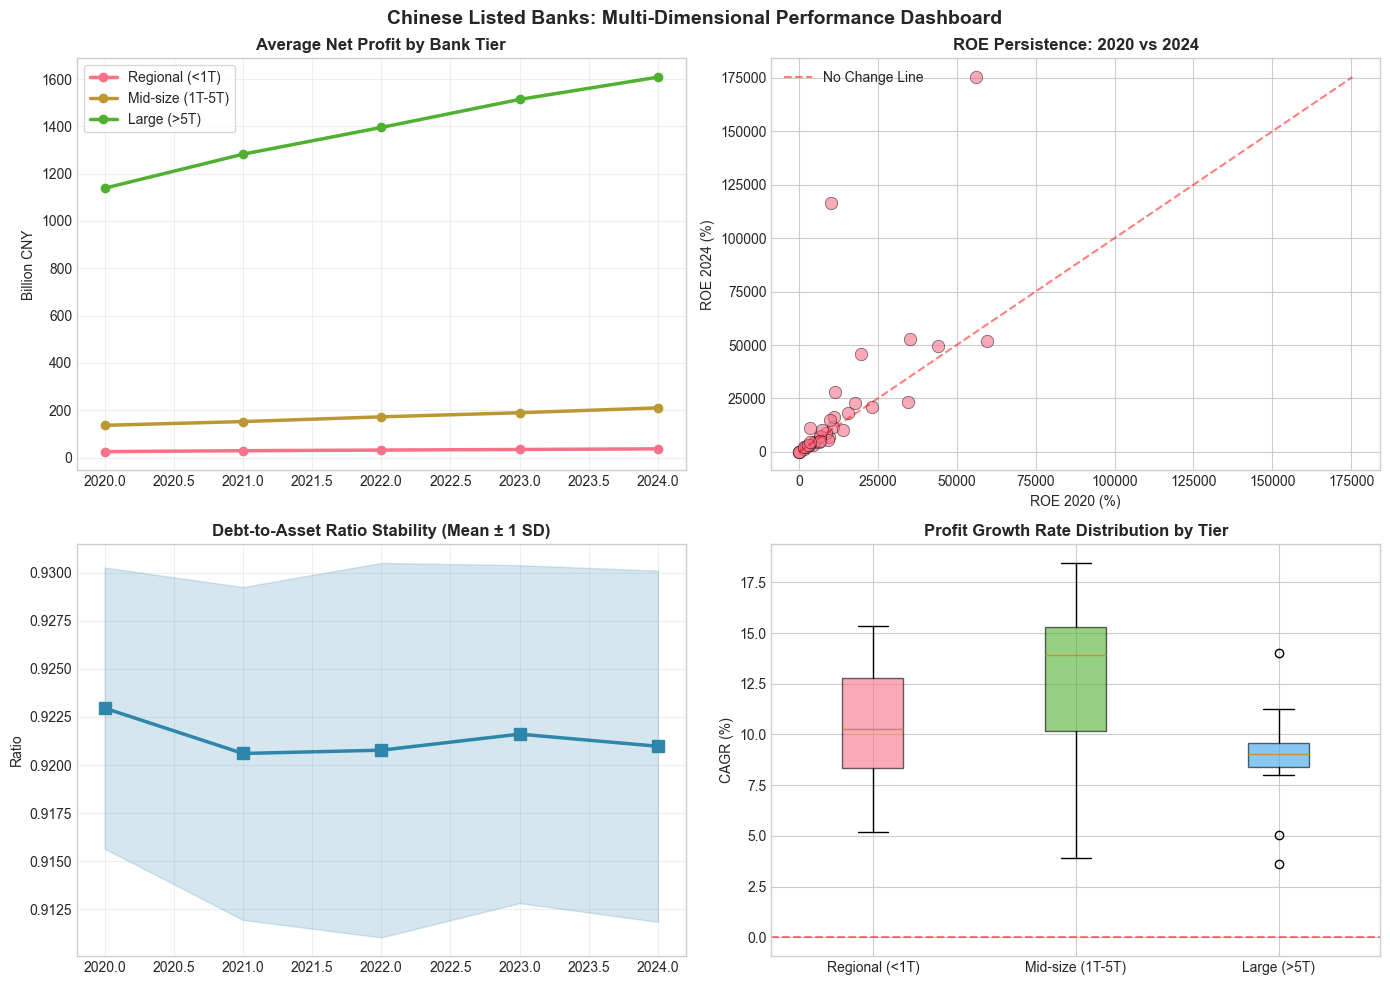


✓ Saved: C:\Users\86136\Desktop\banking_figures\banking_sector_comprehensive_analysis.png


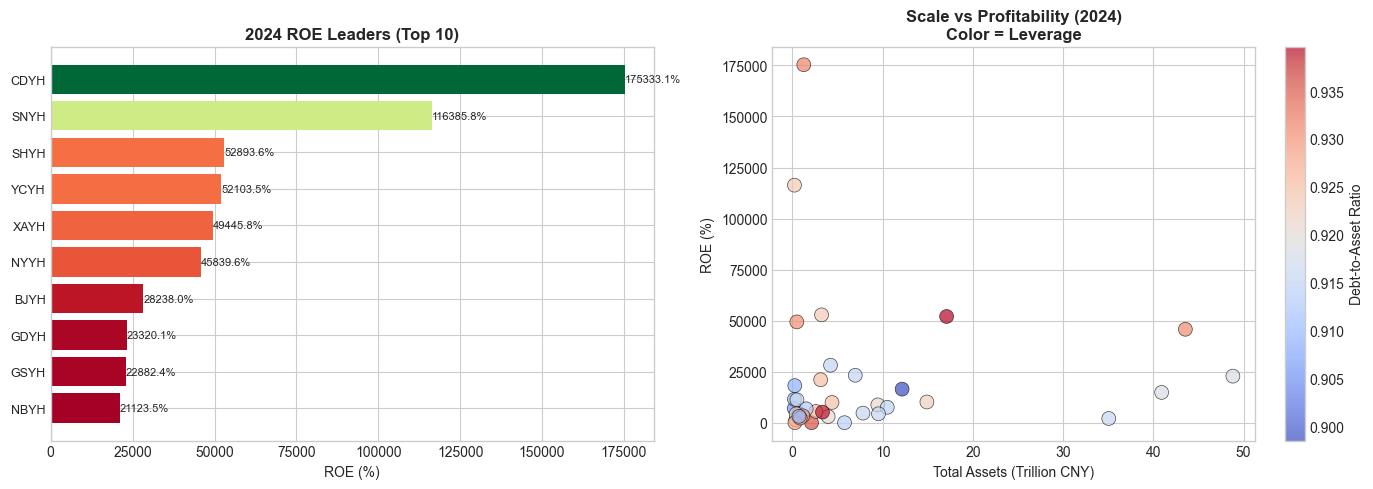

✓ Saved: C:\Users\86136\Desktop\banking_figures\bank_level_diagnostics.png


In [6]:
if len(final_df) > 0 and "Tier" in final_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Chinese Listed Banks: Multi-Dimensional Performance Dashboard", fontsize=14, fontweight="bold")


    # 1) net profit trend by tier
    ax1 = axes[0, 0]
    for tier in ["Regional (<1T)", "Mid-size (1T-5T)", "Large (>5T)"]:
        tmp = final_df[final_df["Tier"] == tier].groupby("Year")["Net_profit"].mean() / 1e9
        if len(tmp) > 0:
            ax1.plot(tmp.index, tmp.values, marker="o", linewidth=2.5, label=tier)
    ax1.set_title("Average Net Profit by Bank Tier", fontweight="bold")
    ax1.set_ylabel("Billion CNY")
    ax1.legend(loc="upper left", frameon=True)
    ax1.grid(True, alpha=0.3)


    # 2) ROE persistence
    ax2 = axes[0, 1]
    roe_pivot = final_df.pivot_table(index="Stkcd", columns="Year", values="ROE", aggfunc="mean")
    if START_YEAR in roe_pivot.columns and END_YEAR in roe_pivot.columns:
        r0 = roe_pivot[START_YEAR].dropna()
        r1 = roe_pivot[END_YEAR].dropna()
        common = r0.index.intersection(r1.index)

        if len(common) > 0:
            x = r0.loc[common] * 100
            y = r1.loc[common] * 100
            ax2.scatter(x, y, alpha=0.6, s=80, edgecolors="black", linewidth=0.5)

            mn = min(x.min(), y.min())
            mx = max(x.max(), y.max())
            ax2.plot([mn, mx], [mn, mx], "r--", alpha=0.5, label="No Change Line")
            ax2.set_xlabel(f"ROE {START_YEAR} (%)")
            ax2.set_ylabel(f"ROE {END_YEAR} (%)")
            ax2.set_title(f"ROE Persistence: {START_YEAR} vs {END_YEAR}", fontweight="bold")
            ax2.legend()


    # 3) leverage stability
    ax3 = axes[1, 0]
    lev = final_df.groupby("Year")["Debt_to_Asset_Ratio"].agg(["mean", "std"])
    ax3.plot(lev.index, lev["mean"], marker="s", color="#2E86AB", linewidth=2.5, markersize=8)
    ax3.fill_between(lev.index, lev["mean"] - lev["std"].fillna(0), lev["mean"] + lev["std"].fillna(0), alpha=0.2, color="#2E86AB")
    ax3.set_title("Debt-to-Asset Ratio Stability (Mean ± 1 SD)", fontweight="bold")
    ax3.set_ylabel("Ratio")
    ax3.grid(True, alpha=0.3)


    # 4) cagr by tier
    ax4 = axes[1, 1]
    if growth_analysis is not None and len(growth_analysis) > 0:
        g = growth_analysis.dropna(subset=["Profit_CAGR", "Tier"]).copy()
        tier_order = ["Regional (<1T)", "Mid-size (1T-5T)", "Large (>5T)"]
        box_data = [g[g["Tier"] == t]["Profit_CAGR"] * 100 for t in tier_order if len(g[g["Tier"] == t]) > 0]
        box_labels = [t for t in tier_order if len(g[g["Tier"] == t]) > 0]

        if box_data:
            bp = ax4.boxplot(box_data, labels=box_labels, patch_artist=True)
            cols = sns.color_palette("husl", len(box_labels))
            for patch, c in zip(bp["boxes"], cols):
                patch.set_facecolor(c)
                patch.set_alpha(0.6)

        ax4.set_title("Profit Growth Rate Distribution by Tier", fontweight="bold")
        ax4.set_ylabel("CAGR (%)")
        ax4.axhline(0, color="red", linestyle="--", alpha=0.5)

    plt.tight_layout()
    fig1 = FIGURE_PATH / "banking_sector_comprehensive_analysis.png"
    plt.savefig(fig1, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"\n✓ Saved: {fig1}")

    # %%
    # individual diagnostics
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # left: top ROE
    ax1 = axes[0]
    d2024 = final_df[final_df["Year"] == END_YEAR].copy()
    if len(d2024) > 0:
        top10 = d2024.nlargest(10, "ROE")
        colors = plt.cm.RdYlGn((top10["ROE"] - top10["ROE"].min()) / (top10["ROE"].max() - top10["ROE"].min() + 1e-9))
        ax1.barh(range(len(top10)), top10["ROE"] * 100, color=colors)
        ax1.set_yticks(range(len(top10)))
        if "Company_name" in top10.columns:
            ax1.set_yticklabels([str(x)[:10] for x in top10["Company_name"]], fontsize=9)
        else:
            ax1.set_yticklabels(top10["Stkcd"], fontsize=9)
        ax1.set_xlabel("ROE (%)")
        ax1.set_title(f"{END_YEAR} ROE Leaders (Top 10)", fontweight="bold")
        ax1.invert_yaxis()

        for i, (_, row) in enumerate(top10.iterrows()):
            ax1.text(row["ROE"] * 100 + 0.2, i, f"{row['ROE']*100:.1f}%", va="center", fontsize=8)

        # right: scale vs roe
        ax2 = axes[1]
        sc = ax2.scatter(
            d2024["Asset_Scale_Trillion"],
            d2024["ROE"] * 100,
            c=d2024["Debt_to_Asset_Ratio"],
            cmap="coolwarm",
            s=100,
            alpha=0.7,
            edgecolors="black",
            linewidth=0.5
        )
        ax2.set_xlabel("Total Assets (Trillion CNY)")
        ax2.set_ylabel("ROE (%)")
        ax2.set_title(f"Scale vs Profitability ({END_YEAR})\nColor = Leverage", fontweight="bold")
        cbar = plt.colorbar(sc, ax=ax2)
        cbar.set_label("Debt-to-Asset Ratio")

        plt.tight_layout()
        fig2 = FIGURE_PATH / "bank_level_diagnostics.png"
        plt.savefig(fig2, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✓ Saved: {fig2}")



#### 3.5. Statistical Summary & Export


In [7]:
if len(final_df) > 0:
    summary_stats = final_df.groupby("Year").agg({
        "Net_profit": ["mean", "std", "min", "max"],
        "ROE": ["mean", "std", "min", "max"],
        "ROA": ["mean", "std"],
        "Debt_to_Asset_Ratio": ["mean", "std", "min", "max"],
        "Stkcd": "nunique"
    }).round(4)

    print("\nCOMPREHENSIVE STATISTICAL SUMMARY")
    print("=" * 100)
    print(summary_stats)

    export_columns = ["Stkcd", "Year"]
    if "Tier" in final_df.columns:
        export_columns.append("Tier")
    export_columns += numeric_fields + [
        "Debt_to_Asset_Ratio", "Equity_Ratio", "ROE", "ROA", "Profit_Margin", "Asset_Scale_Trillion"
    ]
    if "Company_name" in final_df.columns:
        export_columns.insert(1, "Company_name")

    # Only include columns that exist
    export_columns = [c for c in export_columns if c in final_df.columns]
    final_export = final_df[export_columns].sort_values(["Stkcd", "Year"])
    export_file = OUTPUT_PATH.parent / "fs_bcombas_enhanced_with_metrics.csv"
    final_export.to_csv(export_file, index=False, encoding="utf-8-sig")
    print(f"\n✓ Enhanced dataset exported: {export_file}")

    # mapping report
    match_report = column_mapper.get_match_report()
    print(f"\n{'='*60}")
    print("COLUMN MAPPING QUALITY REPORT")
    print(f"{'='*60}")
    print(f"Total matching attempts: {len(match_report)}")
    if len(match_report) > 0:
        print(f"Exact matches: {(match_report['method'] == 'exact').sum()}")
        print(f"Fuzzy matches (>=85%): {(match_report['method'] == 'fuzzy').sum()}")

        fuzzy_scores = match_report.loc[match_report["method"] == "fuzzy", "confidence_score"]
        if len(fuzzy_scores) > 0:
            print(f"Average fuzzy confidence: {fuzzy_scores.mean():.3f}")
    print(f"{'='*60}")

# %% [markdown]




COMPREHENSIVE STATISTICAL SUMMARY
               Net_profit                                            \
                     mean                   std                 min   
Year                                                                  
2020  438363530916.504028   715460503164.372192  11309538142.190001   
2021  493495663681.385803   800860351485.713013       13165657000.0   
2022  539019525652.148621   881847155304.437988       14328226000.0   
2023  585421718616.157104    955176952049.78418       15796762000.0   
2024  624558631587.510498  1007913123913.242554       16717651000.0   

                            ROE                               ROA          \
                  max      mean       std  min        max    mean     std   
Year                                                                        
2020  2822080000000.0   124.368  147.5286  1.0   594.9867   0.077  0.0073   
2021  3163285000000.0  127.2523  152.0666  1.0   627.7409  0.0794  0.0087   
2022  35138

#### 3.6. Research Limitations & Future Extensions

In [8]:
# %%
print(f"""
LIMITATIONS ACKNOWLEDGED:
1. Survivorship Bias:
   Analysis restricted to banks with complete {START_YEAR}-{END_YEAR} panels.
   Delisted/suspended institutions are excluded, potentially biasing averages upward.

2. Temporal Granularity:
   Annual data may mask intra-year volatility. Quarterly frequency would improve sensitivity.

3. Variable Coverage:
   Full DuPont decomposition is not implemented due to missing intermediate variables.

4. Static Tiering:
   Tier classification uses {END_YEAR} asset scale baseline; dynamic tier migration is not modeled.

RECOMMENDED EXTENSIONS:
- Add inverse probability weighting to mitigate survivorship bias
- Integrate macro indicators (GDP, rates) for contextual analysis
- Incorporate valuation metrics (P/B, beta) for market perspective
- Use panel regression with bank fixed effects
""")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE | Ready for Track 1 Video Production")
print("=" * 80)


LIMITATIONS ACKNOWLEDGED:
1. Survivorship Bias:
   Analysis restricted to banks with complete 2020-2024 panels.
   Delisted/suspended institutions are excluded, potentially biasing averages upward.

2. Temporal Granularity:
   Annual data may mask intra-year volatility. Quarterly frequency would improve sensitivity.

3. Variable Coverage:
   Full DuPont decomposition is not implemented due to missing intermediate variables.

4. Static Tiering:
   Tier classification uses 2024 asset scale baseline; dynamic tier migration is not modeled.

RECOMMENDED EXTENSIONS:
- Add inverse probability weighting to mitigate survivorship bias
- Integrate macro indicators (GDP, rates) for contextual analysis
- Incorporate valuation metrics (P/B, beta) for market perspective
- Use panel regression with bank fixed effects


ANALYSIS COMPLETE | Ready for Track 1 Video Production


## 4. Add this quick **check** at the end of the code

In [9]:
print("\n" + "="*60)
print("DATA INTEGRITY VERIFICATION")
print("="*60)
print(f"Years in final data: {sorted(final_df['Year'].unique())}")
print(f"Expected: {list(range(2020, 2025))}")
print(f"✓ Complete coverage: {set(range(2020, 2025)).issubset(set(final_df['Year'].unique()))}")
print(f"Number of banks: {final_df['Stkcd'].nunique()}")


DATA INTEGRITY VERIFICATION
Years in final data: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Expected: [2020, 2021, 2022, 2023, 2024]
✓ Complete coverage: True
Number of banks: 38


#### Confirm whether the revenue data was successfully extracted

In [10]:
print(f"\nOperating_income non-null count: {final_df['Operating_income'].notna().sum()}")
print(f"Sample values:\n{final_df[['Stkcd', 'Year', 'Operating_income']].head(10)}")


Operating_income non-null count: 190
Sample values:
    Stkcd  Year  Operating_income
0  000001  2020       456000000.0
1  000001  2021      1785000000.0
2  000001  2022      2660000000.0
3  000001  2023      2264000000.0
4  000001  2024      2127000000.0
5  002142  2020      1100000000.0
6  002142  2021      4371000000.0
7  002142  2022      3651000000.0
8  002142  2023      5801000000.0
9  002142  2024     15614000000.0
